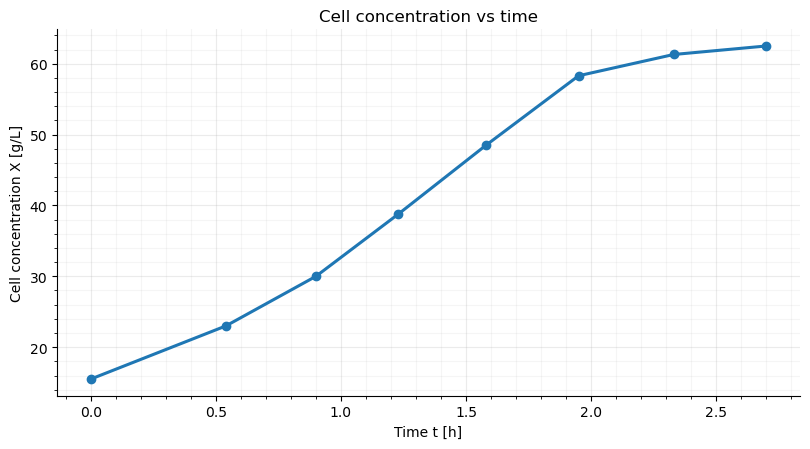

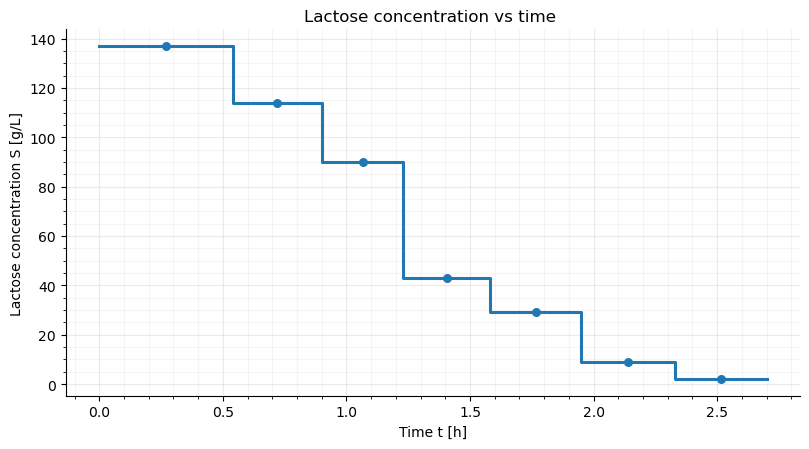

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Data

# time
t0 = np.array([0.00, 0.54, 0.90, 1.23, 1.58, 1.95, 2.33]) # [h]
t1 = np.array([0.54, 0.90, 1.23, 1.58, 1.95, 2.33, 2.70]) # [h]

# Cell concentration 
X0 = np.array([15.5, 23.0, 30.0, 38.8, 48.5, 58.3, 61.3])  # [g/L]
X1 = np.array([23.0, 30.0, 38.8, 48.5, 58.3, 61.3, 62.5])  # [g/L]

# Lactose concentration
S = np.array([137, 114, 90, 43, 29, 9, 2])          # [g/L]

dt = t1 - t0
dXdt = (X1 - X0) / dt               
mu = (1.0 / X0) * dXdt     # (Xmin = X0)

# plotting helper
def plot_helper(ax):
    ax.grid(True, which = "major", alpha = 0.25)
    ax.grid(True, which = "minor", alpha = 0.12)
    ax.minorticks_on()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# A) Plot X(t) and S(t)

# X(t) piecewise linear (connect interval endpoints)
t_plot = np.r_[t0, t1[-1]]
X_plot = np.r_[X0, X1[-1]]

fig, ax = plt.subplots(figsize = (8.2, 4.6))
ax.plot(t_plot, X_plot, marker = "o", linewidth = 2.2, markersize = 6)
ax.set_xlabel("Time t [h]")
ax.set_ylabel("Cell concentration X [g/L]")
ax.set_title("Cell concentration vs time")
plot_helper(ax)
plt.tight_layout()

# S(t) step plot (constant on each interval)
t_step = np.r_[t0, t1[-1]]
S_step = np.r_[S, S[-1]]

fig, ax = plt.subplots(figsize = (8.2, 4.6))
ax.step(t_step, S_step, where = "post", linewidth = 2.2)
ax.scatter((t0 + t1)/2, S, s = 30)  # markers at mid-interval to show the constant value
ax.set_xlabel("Time t [h]")
ax.set_ylabel("Lactose concentration S [g/L]")
ax.set_title("Lactose concentration vs time ")
plot_helper(ax)
plt.tight_layout()

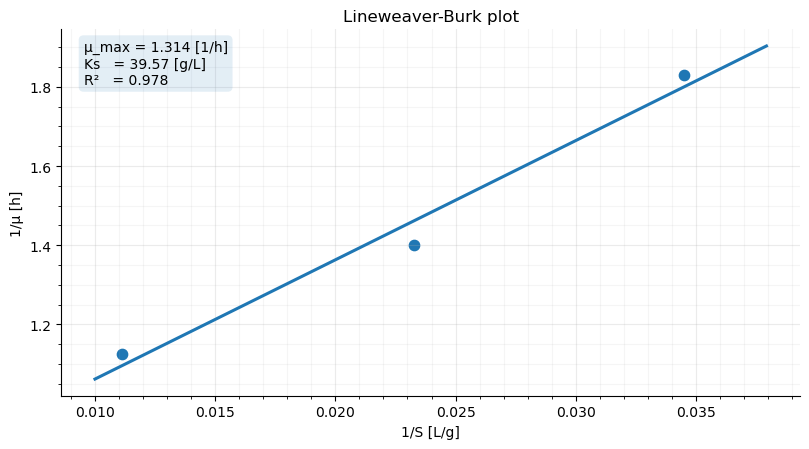

In [41]:
# A) Lineweaver–Burk : 1/μ vs 1/S
# Work only with exponential phase --> choice : intervals 3–5 

idx = np.array([2, 3, 4])

x = 1.0 / S[idx]       # 1/S
y = 1.0 / mu[idx]      # 1/mu

# Fit y = m x + b 
A = np.vstack([x, np.ones_like(x)]).T
m, b = np.linalg.lstsq(A, y, rcond = None)[0]

# Monod LB form:
# 1/mu = (Ks/mu_max)(1/S) + 1/mu_max
mu_max = 1.0 / b
Ks = m * mu_max

# R^2
yhat = m*x + b
ss_res = np.sum((y - yhat)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res/ss_tot

# Plot LB with fitted line
xx = np.linspace(x.min()*0.9, x.max()*1.1, 250)

fig, ax = plt.subplots(figsize = (8.2, 4.6))
ax.scatter(x, y, s = 55)
ax.plot(xx, m*xx + b, linewidth = 2.2)
ax.set_xlabel("1/S [L/g]")
ax.set_ylabel("1/μ [h]")
ax.set_title("Lineweaver-Burk plot")
plot_helper(ax)

# Annotate fit
text = (
    #f"Fit (intervals 1-5)\n" ----------------------------------------------------------
    f"μ_max = {mu_max:.3f} [1/h]\n"
    f"Ks   = {Ks:.2f} [g/L]\n"
    f"R²   = {r2:.3f}")
ax.text(0.03, 0.97, text, transform = ax.transAxes, va = "top", ha = "left",
        bbox = dict(boxstyle = "round,pad = 0.35", alpha = 0.12, edgecolor = "none"))
plt.tight_layout()
plt.show()


In [42]:
# Doubling time
# td = ln(2)/μ  (choose μ = μmax as "best exponential phase" estimate)
td = np.log(2) / mu_max

print("\n----- Doubling time -----")
print(f"td (using mu_max) = {td:.3f} [h]  = {td*60:.1f} [min]")


----- Doubling time -----
td (using mu_max) = 0.528 [h]  = 31.7 [min]
